### 1. Import necessary libraries

In [1]:
import leafmap as lm
import modules.hefs_client as hefs
import modules.map_fldpln as map_fldpln
import modules.nwps_client as nwps
import pandas as pd
import matplotlib.pyplot as plt

### 2. Define gauge ids, api retrieve and mapping function 

In [2]:
# Process

# =======================================
# Setup Parameters
# =======================================

gauge01 = "IDPK1"
gauge02 = "CFVK1"

# =======================================
def CreateMap( fid):
    hefs_g1 = hefs.HEFSGauge(gauge01)
    g1_flow, date01 = hefs_g1.GetForecastFlowMax(fid)

    hefs_g2 = hefs.HEFSGauge(gauge02)
    g2_flow, date02 = hefs_g2.GetForecastFlowMax(fid)

    nwps_g1 = nwps.NWPSGauge(gauge01)
    g1_stage = nwps_g1.ConvertFlowToStage(g1_flow)

    nwps_g2 = nwps.NWPSGauge(gauge02)
    g2_stage = nwps_g1.ConvertFlowToStage(g2_flow)

    gaugeInfo01 = nwps_g1.GetGaugeInfo()
    gaugeInfo02 = nwps_g2.GetGaugeInfo()
    absStage01 = g1_stage + nwps_g1.GetAbsoluteGaugeHeight()
    absStage02 = g2_stage + nwps_g2.GetAbsoluteGaugeHeight()


    x1,y1 = nwps_g1.GetGaugeProjectedXY()
    x2,y2 = nwps_g2.GetGaugeProjectedXY()

    gaugeStageDf = pd.DataFrame({
        'stationid': [gaugeInfo01["lid"], gaugeInfo02["lid"]],
        'x' : [x1,x2],
        'y' : [y1,y2],
        'stage_elevation' : [absStage01, absStage02]

    })

    exportName = f'verdigris_{gauge01}_{date01}_{gauge02}_{date02}'

    map_fldpln.ComputeDepthMap(gaugeStageDf, exportName)

    print(f"{gauge01} Date : {date01}")
    print(f'Flow : {g1_flow} | Stage : {g1_stage}')

    print(f"{gauge02} Date : {date02}")
    print(f'Flow : {g2_flow} | Stage : {g2_stage}')

    map_path = f"exports/{exportName}/{exportName}.tif"

    gauges_df = pd.DataFrame({
        'stationid': [gaugeInfo01["lid"], gaugeInfo02["lid"]],
        'lat' : [gaugeInfo01["lat"], gaugeInfo02["lat"]],
        'lon' : [gaugeInfo01["lon"], gaugeInfo02["lon"]],
        'stage_elevation' : [g1_stage, g2_stage],
        'datetime' : [date01, date02]     
    })

    return (
        map_path,
        gauges_df
    )
    

### 3. Set the forecast ids and create all depth maps

In [4]:
# ===============================================
# forcast ID is an integer value representing 
# how many 6 hours ahead the forecast is made. 
# For example, forcastID = 0 means current time,
# forcastID = 1 means 6 hours ahead
# forcastID = 4 means 24 hours ahead

forecastIds = [0, 1]

# ===============================================
# Create depth maps for all forecast Ids

depthmap_paths = []
gauges_df = []
for fid in forecastIds:
    d_path, g_df = CreateMap(fid)
    depthmap_paths.append(d_path)
    gauges_df.append(g_df)

# ===============================================



verdigris has 10 stream networks.
Processing stream network with outlet segment 27 ...
Original reach network/tree (1 reaches):
[[0, [27, 26], 'TO']]
No gauged reaches found in the stream network.
Processing stream network with outlet segment 37 ...
Original reach network/tree (1 reaches):
[[0, [37, 36, 35, 34, 33], 'TO']]
No gauged reaches found in the stream network.
Processing stream network with outlet segment 56 ...
Original reach network/tree (1 reaches):
[[0, [56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38], 'TO']]
No gauged reaches found in the stream network.
Processing stream network with outlet segment 108 ...
Original reach network/tree (1 reaches):
[[0, [108, 107, 106], 'TO']]
No gauged reaches found in the stream network.
Processing stream network with outlet segment 110 ...
Original reach network/tree (3 reaches):
[[1, [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1], 'TC'], [2, [21, 20, 19, 18, 17, 16], 'TC'], [0, [110, 109], 'CO']]
No gau

### 4. Plot the gauge stage 

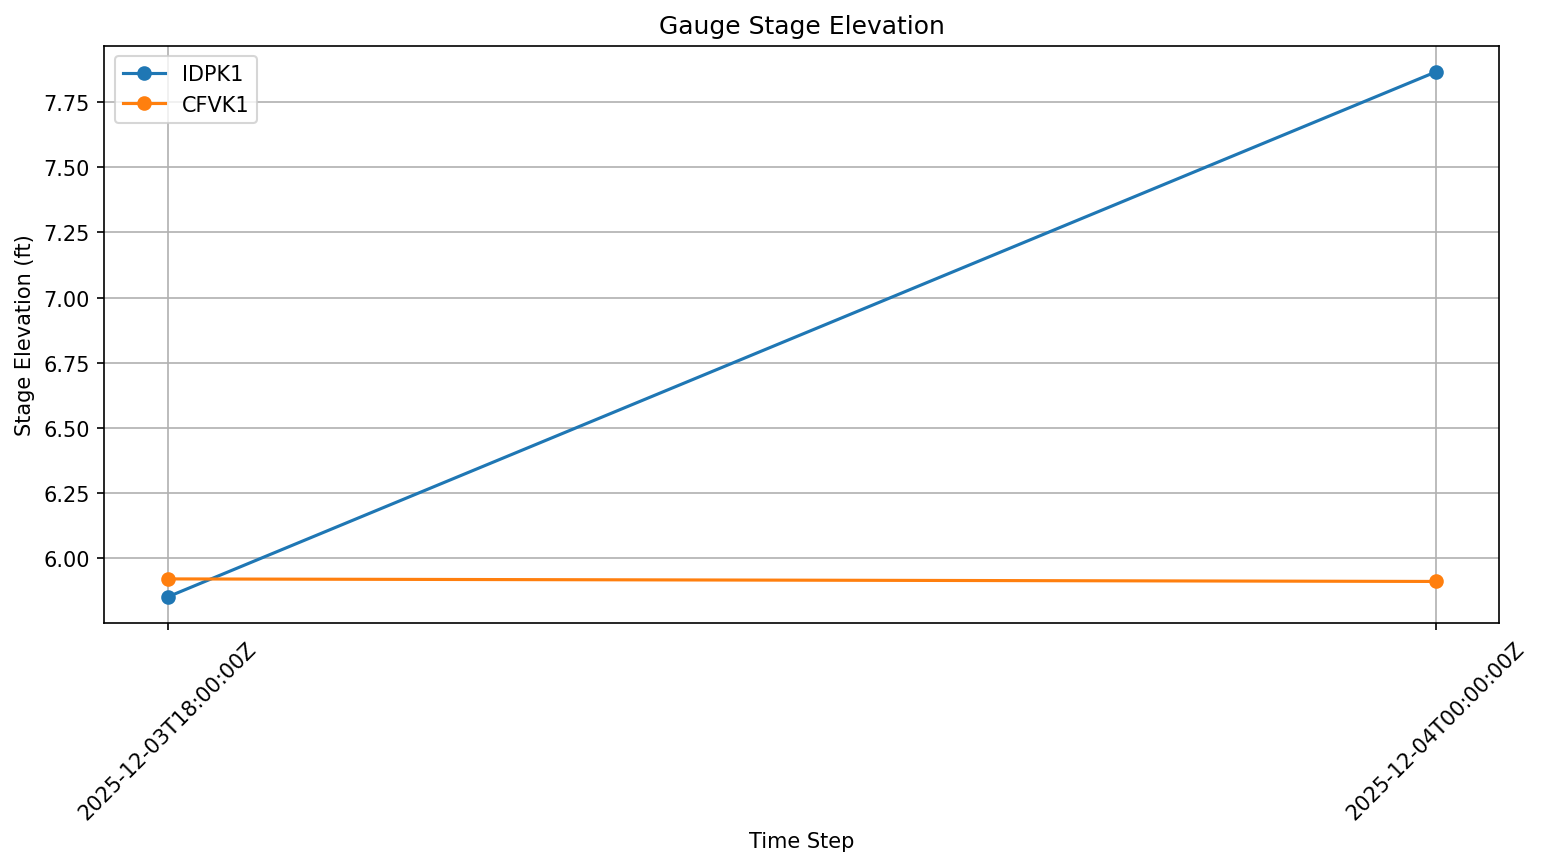

In [ ]:
# the data frame has two gagues information as list per column now plot all stage elevation vs datetime

g1stages = []
g2stages = []
x_labels = []
for g_df in gauges_df:
    g1stages.append(g_df['stage_elevation'][0])
    x_labels.append(g_df['datetime'][0])


for g_df in gauges_df:
    g2stages.append(g_df['stage_elevation'][1])


plt.figure(figsize=(12,5), dpi=150)
plt.plot( g1stages, marker='o')
plt.plot( g2stages, marker='o')
plt.legend([gauge01, gauge02])
plt.xticks(range(len(x_labels)), x_labels, rotation=45)
plt.title('Gauge Stage Elevation')
plt.xlabel('Time Step')
plt.ylabel('Stage Elevation (ft)')
plt.grid()
plt.show()


### 5. Add gauges and all depth maps to interactive map

In [5]:
m = lm.Map(center=[39.0, -96.0], zoom=4, height="800px")
m.add_basemap("SATELLITE")


for depthmap_path in depthmap_paths:
    m.add_raster(depthmap_path, layer_name= depthmap_path[-24:-4] , colormap="viridis", nodata=-9999)

m.add_circle_markers_from_xy(
    gauges_df[0],
    x="lon",
    y="lat",
    popup=["stationid"],
    layer_name="Gauges",
    radius=8, color="white",fill_color="orange", fill_opacity=1
)
m


Map(center=[37.144705, -95.6374215], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

Extra #1 Plot rating curves

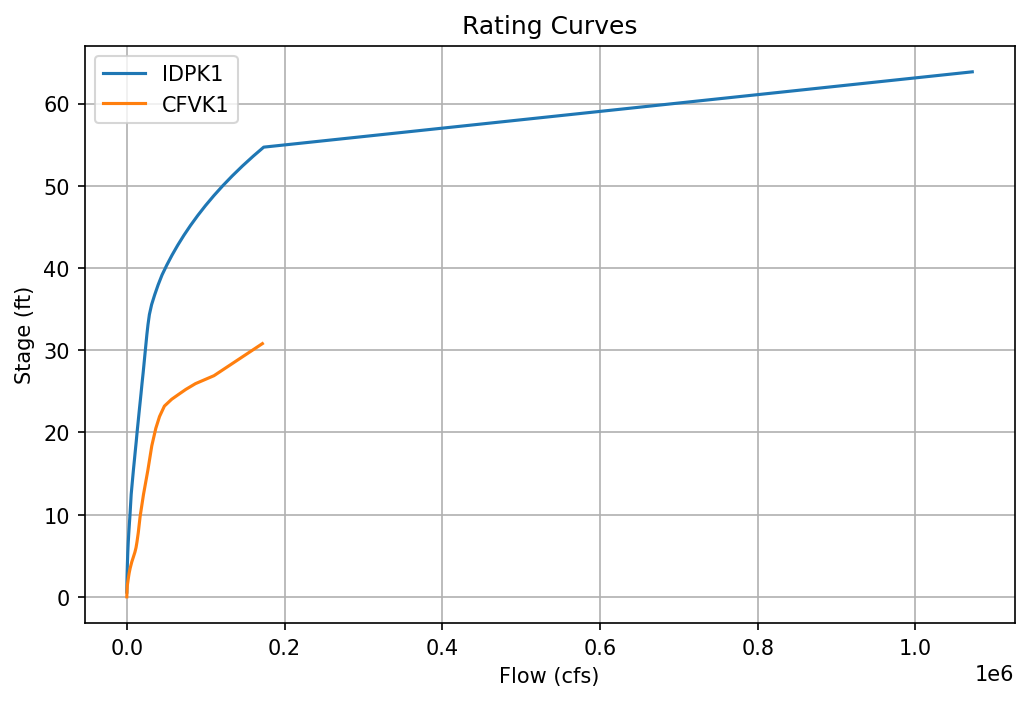

In [ ]:
# plot rating curves for both gauges
gauge1 = nwps.NWPSGauge(gauge01)
rating_curve1 = gauge1._FetchRatingCurve()
gauge2 = nwps.NWPSGauge(gauge02)
rating_curve2 = gauge2._FetchRatingCurve()

plt.figure(figsize=(8,5), dpi=150)
plt.plot( [point[0] for point in rating_curve1], [point[1] for point in rating_curve1] , label=gauge01)
plt.plot( [point[0] for point in rating_curve2], [point[1] for point in rating_curve2] , label=gauge02)
plt.xlabel('Flow (cfs)')
plt.ylabel('Stage (ft)')
plt.title('Rating Curves')
plt.legend()
plt.grid()
plt.show()





Extra 2# Delete cache files

In [37]:
import shutil
import os
export_folder = 'exports/'
for folder_name in os.listdir(export_folder):
    folder_path = os.path.join(export_folder, folder_name)
    if os.path.isdir(folder_path):
        try:
            shutil.rmtree(folder_path)
            print(f"Non-empty folder '{folder_path}' and its contents deleted successfully.")
        except OSError as e:
            print(f"Error deleting non-empty folder: {e}")




Non-empty folder 'exports/verdigris_IDPK1_2025-12-03T18:00:00Z_CFVK1_2025-12-03T18:00:00Z' and its contents deleted successfully.
Non-empty folder 'exports/scratch' and its contents deleted successfully.
Non-empty folder 'exports/verdigris_IDPK1_2025-12-04T00:00:00Z_CFVK1_2025-12-04T00:00:00Z' and its contents deleted successfully.


In [ ]:
# open one raster in matplotlib 


